<a href="https://colab.research.google.com/github/tinemyumi/saude-mental-datasus/blob/main/notebooks/5.eda_sociodemografico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Perfil Sociodemográfico**

## **Objetivo**
Descrever o perfil dos pacientes internados em saúde mental (SP, 2015–2025)
segundo idade, sexo, raça/cor e padrão de reinternação, comparando os três períodos pandêmicos.

## **Conteúdo**
- 1. Setup
- 2. Carregamento e Preparo
- 3. Idade
  - 3.1 Distribuição geral
  - 3.2 Faixas etárias por período
  - 3.3 Teste estatístico (idade)
- 4. Sexo
  - 4.1 Proporção por período
  - 4.2 Idade mediana por sexo e período
- 5. Etnia/Cor
  - 5.1 Proporção por período
  - 5.2 Subnotificação ao longo do tempo
  - 5.3 Interseccionalidade: Etnia × sexo

## **Histórico de Alterações**
- **Data: 08.02.2026** | **Autor: Larissa Yumi Tinem** |


## **1. Setup**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Paleta e estilo
COLOR1 = '#1B4F72'
COLOR2 = '#48C9B0'
COLOR3 = '#5499C7'
PALETTE_PERIODO = {
    'Pre-Pandemia' : COLOR1,
    'Pandemia'     : COLOR2,
    'Pos-Pandemia' : COLOR3,
}
ORDEM_PERIODOS = ['Pre-Pandemia', 'Pandemia', 'Pos-Pandemia']

plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

SAVEPATH = '/content/drive/MyDrive/Dataframes/'

## **2. Carregamento e Preparo**

In [ ]:
PATH = '/content/drive/MyDrive/Dataframes/df_sih_sus_tratado/df_saude_mental_consolidado.parquet'
df = pd.read_parquet(PATH)

df['periodo'] = pd.Categorical(df['periodo'], categories=ORDEM_PERIODOS, ordered=True)

print(f'Shape: {df.shape}')
df.head(3)

Shape: (1079670, 24)


,UF_ZI,ANO_CMPT,MES_CMPT,NASC,IDADE,SEXO,RACA_COR,ESPEC,IDENT,MUNIC_RES,...,MUNIC_MOV,CID_ASSO,CID_MORTE,COMPLEX,DT_INTER,DT_SAIDA,QT_DIARIAS,DIAS_PERM,MORTE,periodo
0,351880,2015,1,1971-10-30,43,3,01,05,1,351880,...,351880,0000,0000,02,2014-12-28,2014-12-31,3,3,0,Pre-Pandemia
1,351880,2015,1,1972-03-05,42,1,99,05,1,351880,...,351880,0000,0000,02,2014-12-16,2014-12-20,4,4,0,Pre-Pandemia
2,351880,2015,1,1972-09-25,42,3,99,05,1,351880,...,351880,0000,0000,02,2014-12-29,2015-01-05,7,7,0,Pre-Pandemia


In [ ]:
# Decodificações

df['SEXO_DESC'] = df['SEXO'].map({'1': 'Masculino', '3': 'Feminino'})

df['ETNIA_DESC'] = df['RACA_COR'].map({
    '01': 'Branca',
    '02': 'Parda',
    '03': 'Preta',
    '04': 'Amarela',
    '05': 'Indígena',
    '99': 'Ignorado'
})

df['FAIXA_ETARIA'] = pd.cut(
    df['IDADE'],
    bins=[0, 17, 29, 44, 59, 120],
    labels=['0–17', '18–29', '30–44', '45–59', '60+'],
    right=True
)

print('Decodificações aplicadas.')
print(df[['SEXO_DESC', 'ETNIA_DESC', 'FAIXA_ETARIA']].nunique())

Decodificações aplicadas.
SEXO_DESC       2
ETNIA_DESC      6
FAIXA_ETARIA    5
dtype: int64


## **3. Idade**

### **3.1 Distribuição Geral**


In [ ]:
# Estatísticas descritivas de idade por período
idade_desc = (
    df.groupby('periodo', observed=True)['IDADE']
    .agg(media='mean', mediana='median', dp='std', p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75))
    .round(1)
)
print(idade_desc)

              media  mediana    dp   p25   p75
periodo                                       
Pre-Pandemia   44.5     44.0  16.3  32.0  56.0
Pandemia       42.2     41.0  15.8  30.0  53.0
Pos-Pandemia   40.6     40.0  14.9  29.0  50.0


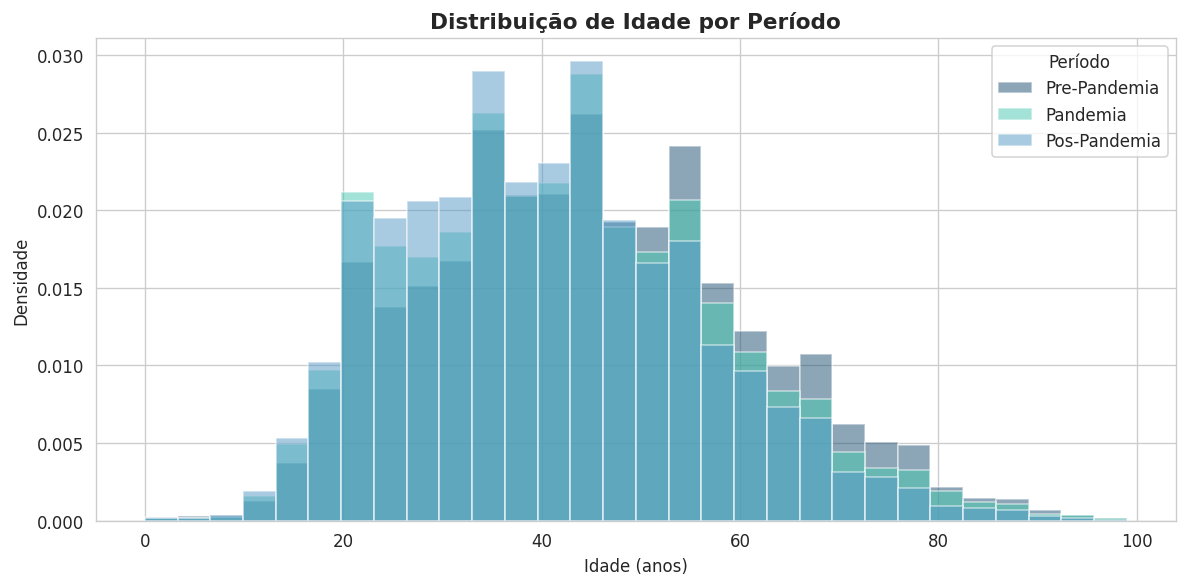

In [ ]:
# Histograma de idade por período (sobrepostos)
fig, ax = plt.subplots(figsize=(10, 5))

for periodo in ORDEM_PERIODOS:
    dados = df[df['periodo'] == periodo]['IDADE']
    ax.hist(dados, bins=30, alpha=0.5, label=periodo,
            color=PALETTE_PERIODO[periodo], density=True, edgecolor='white')

ax.set_title('Distribuição de Idade por Período', fontsize=13, fontweight='bold')
ax.set_xlabel('Idade (anos)')
ax.set_ylabel('Densidade')
ax.legend(title='Período')
plt.tight_layout()
plt.show()

/tmp/ipykernel_822/1037992695.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


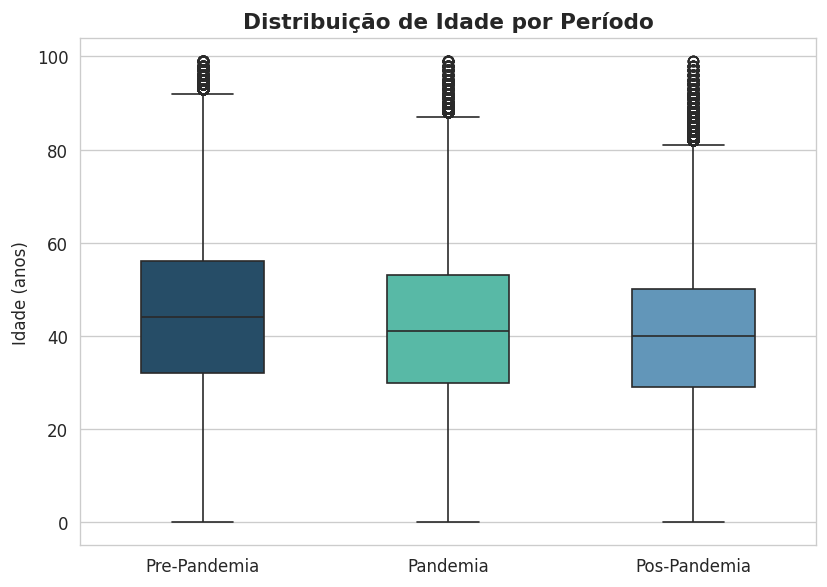

In [ ]:
# Boxplot de idade por período
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(
    data=df, x='periodo', y='IDADE',
    palette=PALETTE_PERIODO,
    order=ORDEM_PERIODOS,
    width=0.5, ax=ax
)

ax.set_title('Distribuição de Idade por Período', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Idade (anos)')
plt.tight_layout()
plt.show()

### **3.2 Faixas Etárias por Período**

In [ ]:
# Proporção de cada faixa etária dentro de cada período
tabela_faixa = (
    df.groupby(['periodo', 'FAIXA_ETARIA'], observed=True)
    .size()
    .unstack(fill_value=0)
)
prop_faixa = tabela_faixa.div(tabela_faixa.sum(axis=1), axis=0) * 100
print(prop_faixa.round(1))

FAIXA_ETARIA  0–17  18–29  30–44  45–59   60+
periodo                                      
Pre-Pandemia   2.6   17.2   32.1   29.9  18.3
Pandemia       3.1   20.9   33.8   28.0  14.3
Pos-Pandemia   3.4   22.6   36.3   26.3  11.4


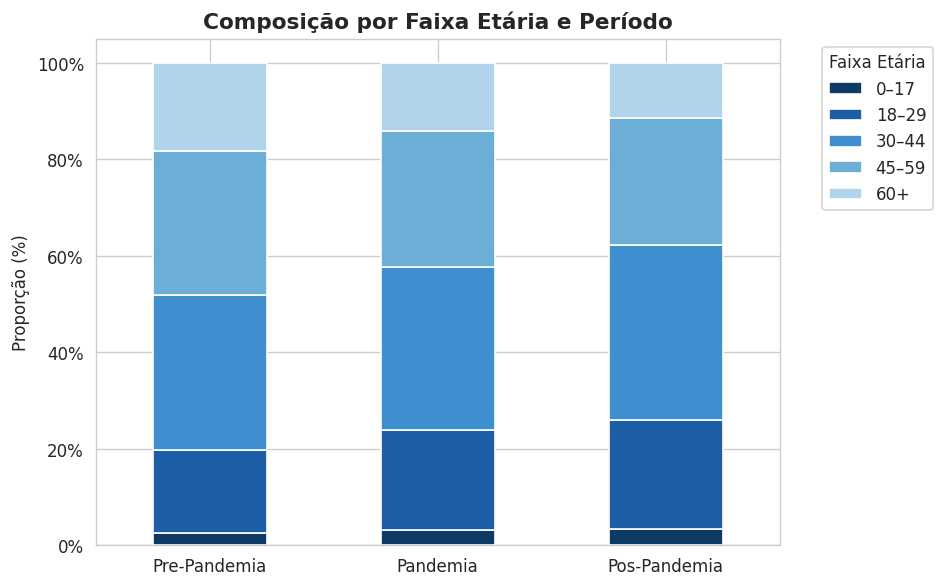

In [ ]:
# Gráfico de barras empilhadas: faixa etária por período
cores_faixas = ['#0D3B66', '#1D5FA7', '#3E8ED0', '#6BAED6', '#B0D4EC']

fig, ax = plt.subplots(figsize=(8, 5))
prop_faixa.plot(kind='bar', stacked=True, ax=ax,
                color=cores_faixas, edgecolor='white', width=0.5)

ax.set_title('Composição por Faixa Etária e Período', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Proporção (%)')
ax.set_xticklabels(ORDEM_PERIODOS, rotation=0)
ax.legend(title='Faixa Etária', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.show()

### **3.3 Teste Estatístico (Idade)**

In [ ]:
# Kruskal-Wallis: a distribuição de idade difere entre períodos?
grupos_idade = [df[df['periodo'] == p]['IDADE'].values for p in ORDEM_PERIODOS]
stat, p_val = stats.kruskal(*grupos_idade)

print('=== Kruskal-Wallis — Idade por Período ===================')
print(f'H = {stat:.4f} | p-valor = {p_val:.4e}')
print(f'Conclusão: {"Distribuição de idade difere significativamente" if p_val < 0.05 else "Sem diferença significativa"} entre períodos (α=0.05)')

=== Kruskal-Wallis — Idade por Período ===================
H = 11783.7190 | p-valor = 0.0000e+00
Conclusão: Distribuição de idade difere significativamente entre períodos (α=0.05)


## **4. Sexo**

### **4.1 Proporção por Período**

In [ ]:
# Proporção de internações por sexo e período
tabela_sexo = (
    df.groupby(['periodo', 'SEXO_DESC'], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(ORDEM_PERIODOS)
)
prop_sexo = tabela_sexo.div(tabela_sexo.sum(axis=1), axis=0) * 100
print(prop_sexo.round(1))

SEXO_DESC     Feminino  Masculino
periodo                          
Pre-Pandemia      37.6       62.4
Pandemia          38.4       61.6
Pos-Pandemia      39.0       61.0


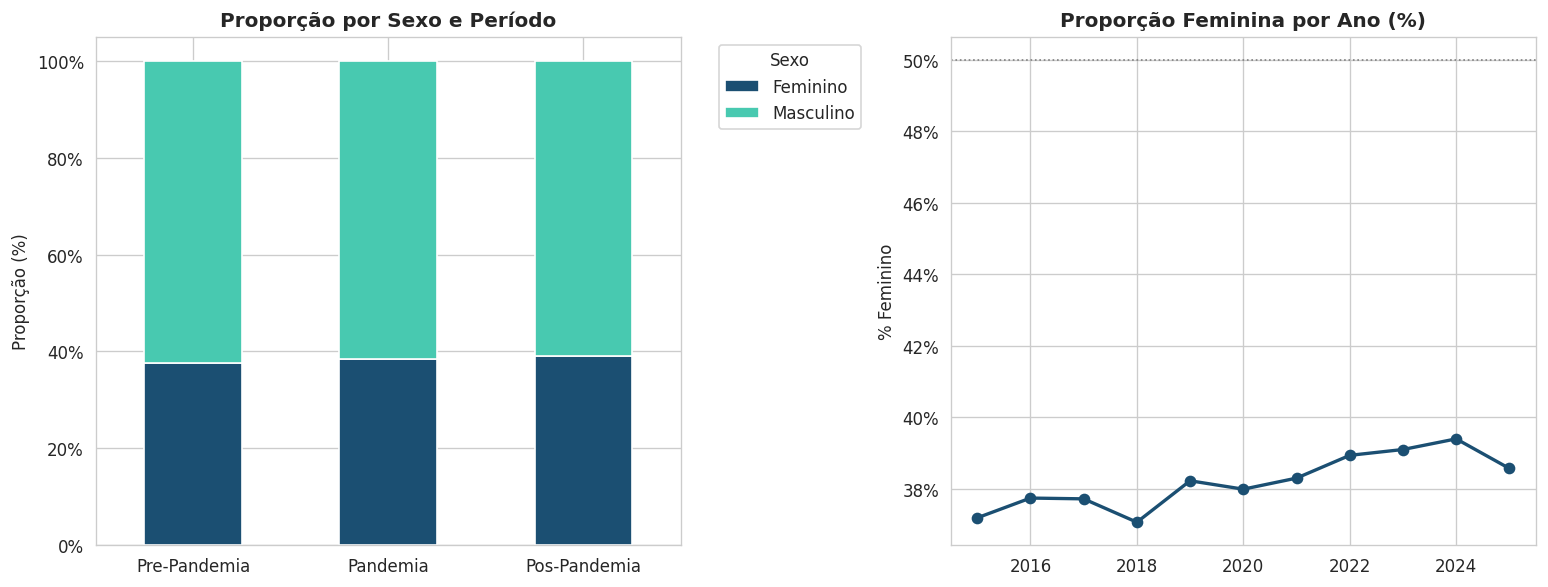

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras empilhadas
prop_sexo.plot(kind='bar', stacked=True, ax=axes[0],
               color=[COLOR1, COLOR2], edgecolor='white', width=0.5)
axes[0].set_title('Proporção por Sexo e Período', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Proporção (%)')
axes[0].set_xticklabels(ORDEM_PERIODOS, rotation=0)
axes[0].legend(title='Sexo', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# Evolução anual da proporção feminina
prop_fem_anual = (
    df.assign(feminino=df['SEXO_DESC'] == 'Feminino')
    .groupby('ANO_CMPT')['feminino']
    .mean() * 100
)
axes[1].plot(prop_fem_anual.index, prop_fem_anual.values,
             marker='o', color=COLOR1, linewidth=2)
axes[1].axhline(50, color='grey', linestyle=':', linewidth=1)
axes[1].set_title('Proporção Feminina por Ano (%)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('% Feminino')
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.show()

### **4.2 Idade Mediana por Sexo e Período**

In [ ]:
# Cruza sexo × período para ver se o perfil de idade difere
idade_sexo = (
    df.groupby(['periodo', 'SEXO_DESC'], observed=True)['IDADE']
    .agg(media='mean', mediana='median', dp='std')
    .round(1)
)
print(idade_sexo)

                        media  mediana    dp
periodo      SEXO_DESC                      
Pre-Pandemia Feminino    45.8     45.0  16.8
             Masculino   43.8     43.0  15.9
Pandemia     Feminino    42.4     42.0  16.1
             Masculino   42.1     41.0  15.6
Pos-Pandemia Feminino    41.1     40.0  15.7
             Masculino   40.3     39.0  14.4


## **5. Etnia/Cor**

### **5.1 Proporção por Período**

In [ ]:
# Exclui Ignorado para o gráfico principal (mantém para subnotificação)
df_raca = df[df['ETNIA_DESC'] != 'Ignorado'].copy()

tabela_raca = (
    df_raca.groupby(['periodo', 'ETNIA_DESC'], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(ORDEM_PERIODOS)
)
prop_raca = tabela_raca.div(tabela_raca.sum(axis=1), axis=0) * 100
print(prop_raca.round(1))

ETNIA_DESC    Amarela  Branca  Indígena  Parda  Preta
periodo                                              
Pre-Pandemia      0.6    63.5       0.0   10.2   25.6
Pandemia          0.6    59.5       0.0   10.2   29.7
Pos-Pandemia      0.7    55.1       0.0    9.2   35.0


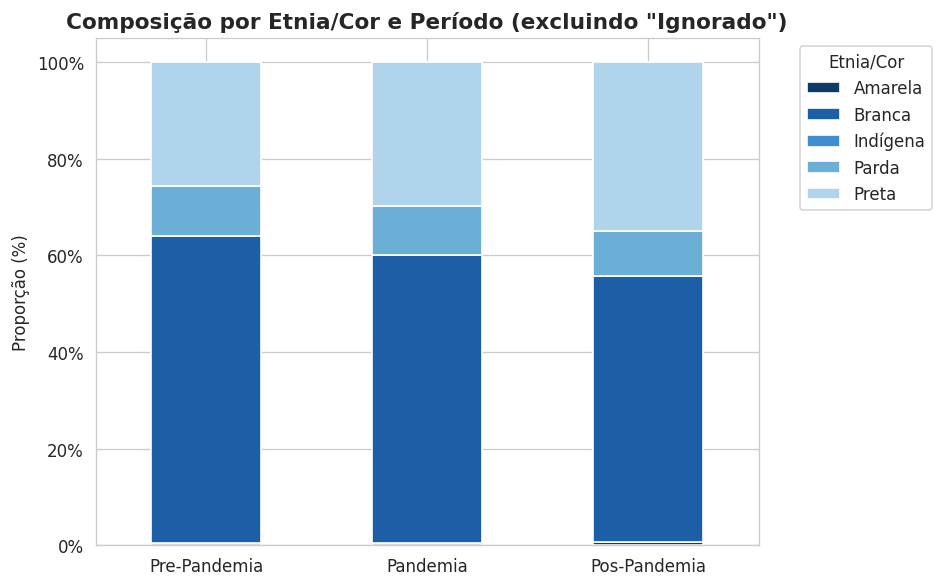

In [ ]:
cores_raca = ['#0D3B66', '#1D5FA7', '#3E8ED0', '#6BAED6', '#B0D4EC']

fig, ax = plt.subplots(figsize=(8, 5))
prop_raca.plot(kind='bar', stacked=True, ax=ax,
               color=cores_raca, edgecolor='white', width=0.5)

ax.set_title('Composição por Etnia/Cor e Período (excluindo "Ignorado")',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Proporção (%)')
ax.set_xticklabels(ORDEM_PERIODOS, rotation=0)
ax.legend(title='Etnia/Cor', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.show()

### **5.2 Subnotificação ao Longo do Tempo**


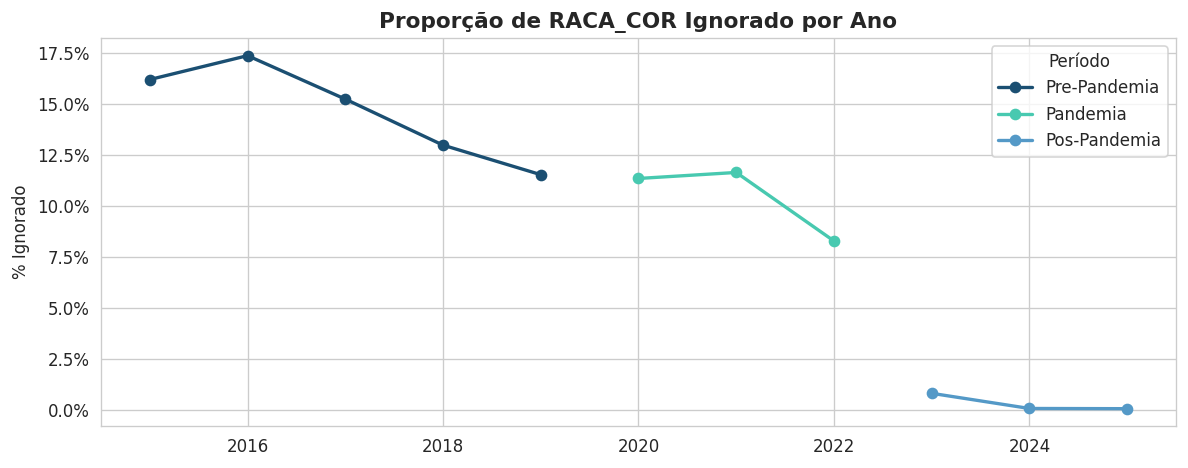

periodo
Pre-Pandemia    14.7
Pandemia        10.4
Pos-Pandemia     0.3
Name: pct_ignorado, dtype: float64


In [ ]:
df['ANO_CMPT'] = df['ANO_CMPT'].astype(int)

# cria coluna booleana
df['ignorado'] = df['ETNIA_DESC'] == 'Ignorado'

# calcula proporção por ano e período
pct_ignorado = (
    df.groupby(['ANO_CMPT', 'periodo'], observed=True)['ignorado']
    .mean()
    .mul(100)
    .reset_index(name='pct_ignorado')
)

fig, ax = plt.subplots(figsize=(10, 4))

for periodo in ORDEM_PERIODOS:
    dados = pct_ignorado[pct_ignorado['periodo'] == periodo]
    ax.plot(
        dados['ANO_CMPT'],
        dados['pct_ignorado'],
        marker='o',
        label=periodo,
        color=PALETTE_PERIODO[periodo],
        linewidth=2
    )

ax.set_title('Proporção de RACA_COR Ignorado por Ano', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('% Ignorado')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(title='Período')

plt.tight_layout()
plt.show()

print(
    pct_ignorado.groupby('periodo', observed=True)['pct_ignorado']
    .mean()
    .round(1)
)

### **5.3 Interseccionalidade: Raça × Sexo**

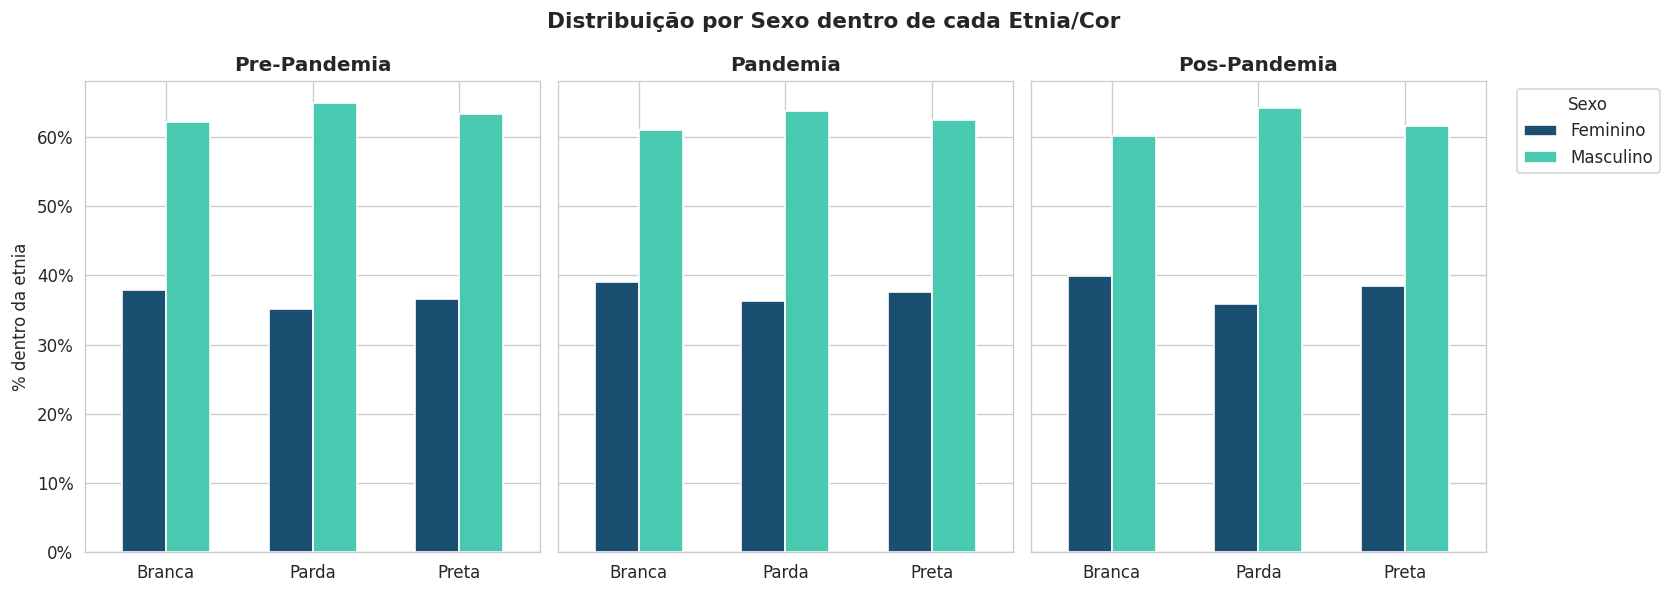

In [ ]:
# Cruza raça e sexo para ver se há padrão diferente de acesso
# Foco em Branca, Parda e Preta (categorias com volume suficiente)
racas_principais = ['Branca', 'Parda', 'Preta']

intersec = (
    df[df['ETNIA_DESC'].isin(racas_principais)]
    .groupby(['ETNIA_DESC', 'SEXO_DESC', 'periodo'], observed=True)
    .size()
    .reset_index(name='quantidade')
)

# Normaliza dentro de cada grupo raça × período
total_raca_periodo = intersec.groupby(['ETNIA_DESC', 'periodo'], observed=True)['quantidade'].transform('sum')
intersec['proporcao'] = intersec['quantidade'] / total_raca_periodo * 100

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, periodo in zip(axes, ORDEM_PERIODOS):
    dados = intersec[intersec['periodo'] == periodo]
    pivot = dados.pivot(index='ETNIA_DESC', columns='SEXO_DESC', values='proporcao')
    pivot.plot(kind='bar', ax=ax, color=[COLOR1, COLOR2], edgecolor='white', width=0.6, legend=(ax == axes[2]))
    ax.set_title(periodo, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(racas_principais, rotation=0)
    ax.set_ylabel('% dentro da etnia' if ax == axes[0] else '')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

fig.suptitle('Distribuição por Sexo dentro de cada Etnia/Cor', fontsize=13, fontweight='bold')
axes[2].legend(title='Sexo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()